# 2018 Point Sampling — K3 24-Month Support

Point-level validation of the padded K3 model.

This notebook keeps the original 2018 field-point and vegetation joins, then samples:

- the original **2018-only K3** derived raster;
- the new **July 2017–June 2019-supported K3** derived raster.

The existing 2018 Sentinel-2 harmonic-input observations are retained as the observed points. This lets us ask the key question directly:

> Does wider temporal support stabilize the K3 edges while preserving the well-supported interior 2018 trajectory?

`RMSE_fit_*` from the padded model is evaluated over a different 24-month observation set and is therefore not directly comparable to the original 2018-only `RMSE_*`.


In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# -------------------------------------------------------------------
# INPUT PATHS
# -------------------------------------------------------------------

POINT_CSV = Path(
    r"N:\Data02\projects-active\BOPclassification_2025"
    r"\Field Data (Processed)\2026"
    r"\MasterPointFeatures_2016to2026.csv"
)

VEG_CSV = Path(
    r"C:\NCA_DATA\Vegetation Data\NCA_Master_Aligned_spp_fg.csv"
)

ROOT = Path(
    r"A:\NCA_DATA\Validation\2018_HarmonicSensitivity"
)

ORIGINAL_K3_TIF = (
    ROOT
    / "Derived_AmpPhase_TIFs"
    / "2018_K3_InterceptAmpPhase_nobs_RMSE.tif"
)

PADDED_K3_TIF = (
    ROOT
    / "K3_24MonthSupport"
    / "Derived_AmpPhase_TIFs"
    / "2018_K3_24MonthSupport_InterceptAmpPhase_nobs_nobsfit_RMSEfit.tif"
)

RAW_LONG_CSV = (
    ROOT
    / "PointSampling"
    / "S2_2018_NCA_117Point_HarmonicInputObservations_LONG.csv"
)

for path in [
    POINT_CSV,
    VEG_CSV,
    ORIGINAL_K3_TIF,
    PADDED_K3_TIF,
    RAW_LONG_CSV,
]:
    if not path.exists():
        raise FileNotFoundError(path)

print("Inputs found.")


Inputs found.


## 1. Rebuild the 2018 NCA point / vegetation join

In [3]:
points = pd.read_csv(POINT_CSV)

points_2018 = (
    points.loc[points["Year"] == 2018]
    .copy()
    .reset_index(drop=True)
)

assert len(points_2018) == 122
assert points_2018["PlotID"].nunique() == 122

points_2018["PlotID"] = points_2018["PlotID"].astype(str)

veg = pd.read_csv(VEG_CSV)

# This X is an index in the vegetation table, not the authoritative GIS X.
if "X" in veg.columns:
    veg = veg.drop(columns="X")

veg_2018 = (
    veg.loc[veg["Year"] == 2018]
    .copy()
    .reset_index(drop=True)
)

veg_2018["Plot_key"] = veg_2018["Plot"].astype(str)

FG_COLS = [
    "BAREGROUND_FG",
    "BIOCRUST_FG",
    "EAG_FG",
    "EF_FG",
    "LITTER_FG",
    "NPF_FG",
    "PBG_FG",
    "SHRUB_FG",
    "SHRUB_total",
    "total_cover_fg",
]

veg_join = veg_2018[
    ["Plot_key", "Plot", *FG_COLS]
].copy()

nca_2018 = points_2018.merge(
    veg_join,
    left_on="PlotID",
    right_on="Plot_key",
    how="left",
    validate="one_to_one",
)

nca_2018_veg = (
    nca_2018.loc[nca_2018["Plot"].notna()]
    .copy()
    .reset_index(drop=True)
)

assert len(nca_2018_veg) == 117

print("2018 NCA points:", len(points_2018))
print("Matched vegetation points:", len(nca_2018_veg))
print(
    "Unmatched:",
    sorted(
        set(points_2018["PlotID"])
        - set(nca_2018_veg["PlotID"])
    )
)


2018 NCA points: 122
Matched vegetation points: 117
Unmatched: ['100', '121', '196', '211', '220']


## 2. Sample original K3 and padded K3 at the same 117 point locations

In [4]:
def raster_band_lookup(src):

    descriptions = list(src.descriptions)

    if any(d is None for d in descriptions):
        raise RuntimeError(
            f"{src.name} contains unnamed bands."
        )

    return {
        name: i
        for i, name in enumerate(descriptions, start=1)
    }


def sample_raster_at_points(
    raster_path,
    point_df,
):

    with rasterio.open(raster_path) as src:

        lookup = raster_band_lookup(src)

        coords = list(
            zip(
                point_df["X"].astype(float),
                point_df["Y"].astype(float),
            )
        )

        values = np.asarray(
            list(
                src.sample(
                    coords,
                    indexes=list(range(1, src.count + 1)),
                    masked=False,
                )
            ),
            dtype=np.float32,
        )

        df = pd.DataFrame(
            values,
            columns=list(src.descriptions),
        )

        if src.nodata is not None:
            df = df.replace(src.nodata, np.nan)

        df.insert(
            0,
            "PlotID",
            point_df["PlotID"].astype(str).to_numpy(),
        )

    return df


sampled_original_k3 = sample_raster_at_points(
    ORIGINAL_K3_TIF,
    nca_2018_veg,
)

sampled_padded_k3 = sample_raster_at_points(
    PADDED_K3_TIF,
    nca_2018_veg,
)

print(
    "Original K3:",
    sampled_original_k3.shape
)

print(
    "Padded K3:",
    sampled_padded_k3.shape
)


Original K3: (117, 122)
Padded K3: (117, 123)


## 3. Observation-count QA

In [5]:
nobs_compare = sampled_original_k3[
    ["PlotID", "nobs"]
].rename(
    columns={"nobs": "original_nobs"}
).merge(
    sampled_padded_k3[
        ["PlotID", "nobs", "nobs_fit"]
    ].rename(
        columns={
            "nobs": "padded_focal_nobs",
            "nobs_fit": "padded_fit_nobs",
        }
    ),
    on="PlotID",
    how="inner",
    validate="one_to_one",
)

nobs_compare["focal_nobs_difference"] = (
    nobs_compare["padded_focal_nobs"]
    - nobs_compare["original_nobs"]
)

nobs_compare["additional_fit_observations"] = (
    nobs_compare["padded_fit_nobs"]
    - nobs_compare["padded_focal_nobs"]
)

display(nobs_compare)

print(
    "\nFocal-year nobs differences:"
)
print(
    nobs_compare["focal_nobs_difference"]
    .value_counts(dropna=False)
    .sort_index()
)

print(
    "\nAdditional observations supplied by padding:"
)
display(
    nobs_compare["additional_fit_observations"]
    .describe()
)


,PlotID,original_nobs,padded_focal_nobs,padded_fit_nobs,focal_nobs_difference,additional_fit_observations
0,109,64.0,64.0,132.0,0.0,68.0
1,110,65.0,65.0,135.0,0.0,70.0
2,111,65.0,65.0,134.0,0.0,69.0
3,112,63.0,63.0,120.0,0.0,57.0
4,113,69.0,69.0,140.0,0.0,71.0
...,...,...,...,...,...,...
112,104,68.0,68.0,139.0,0.0,71.0
113,105,68.0,68.0,139.0,0.0,71.0
114,106,67.0,67.0,135.0,0.0,68.0
115,107,65.0,65.0,133.0,0.0,68.0



Focal-year nobs differences:
focal_nobs_difference
0.0    116
NaN      1
Name: count, dtype: int64

Additional observations supplied by padding:


count    116.000000
mean      61.189655
std       15.822340
min        7.000000
25%       62.250000
50%       69.000000
75%       70.250000
max       78.000000
Name: additional_fit_observations, dtype: float64

## 4. Load the exact 2018 Sentinel-2 observations used by the original harmonic fit

In [6]:
raw_long = pd.read_csv(
    RAW_LONG_CSV,
    parse_dates=["date"],
)

raw_long["PlotID"] = raw_long["PlotID"].astype(str)

VALID_2018_PLOTS = sorted(
    raw_long["PlotID"]
    .unique()
)

print("Valid 2018 plots:", len(VALID_2018_PLOTS))
print(
    "Observation count per plot:"
)
display(
    raw_long.groupby("PlotID")
    .size()
    .describe()
)


Valid 2018 plots: 116
Observation count per plot:


count    116.000000
mean      59.232759
std       13.911745
min       13.000000
25%       59.500000
50%       66.000000
75%       68.000000
max       72.000000
dtype: float64

## 5. Reconstruction helpers

In [7]:
DATES_2018 = pd.date_range(
    "2018-01-01",
    "2018-12-31",
    freq="D",
)

T_2018 = np.arange(
    len(DATES_2018)
) / 365.25


def get_row(df, plot_id):

    plot_id = str(plot_id)

    row = df.loc[
        df["PlotID"].astype(str) == plot_id
    ]

    if len(row) != 1:
        raise ValueError(
            f"Expected exactly one row for PlotID {plot_id}; "
            f"found {len(row)}."
        )

    return row.iloc[0]


def reconstruct_k3_from_derived(
    row,
    variable,
):

    curve = np.full(
        len(T_2018),
        float(row[f"constant_{variable}"]),
        dtype=float,
    )

    for h in range(1, 4):

        amplitude = float(
            row[f"amp{h}_{variable}"]
        )

        phase = float(
            row[f"phase{h}_{variable}"]
        )

        curve += amplitude * np.cos(
            h * 2 * np.pi * T_2018
            - phase
        )

    return curve


## 6. Five-index comparison: original K3 vs padded K3

Each panel shows the 2018 observations plus:

- original 2018-only K3;
- padded K3 estimated from July 2017–June 2019 observations.

This is the primary edge-stability diagnostic.


In [8]:
INDEX_VARIABLES = [
    "NDVI",
    "NDMI",
    "NDRE",
    "BSI",
    "NBR2",
]


def plot_pixel_five_indices_padding_comparison(
    plot_id,
    title=None,
):

    plot_id = str(plot_id)

    if plot_id not in VALID_2018_PLOTS:
        raise ValueError(
            f"Plot {plot_id} does not have valid 2018 observations."
        )

    raw_plot = (
        raw_long.loc[
            raw_long["PlotID"] == plot_id
        ]
        .copy()
        .sort_values("date")
    )

    row_original = get_row(
        sampled_original_k3,
        plot_id,
    )

    row_padded = get_row(
        sampled_padded_k3,
        plot_id,
    )

    fig = plt.figure(
        figsize=(16, 13)
    )

    gs = fig.add_gridspec(
        3,
        2,
        hspace=0.30,
        wspace=0.18,
    )

    axes = {
        "NDVI": fig.add_subplot(gs[0, 0]),
        "NDMI": fig.add_subplot(gs[0, 1]),
        "NDRE": fig.add_subplot(gs[1, 0]),
        "BSI": fig.add_subplot(gs[1, 1]),
        "NBR2": fig.add_subplot(gs[2, :]),
    }

    for variable in INDEX_VARIABLES:

        ax = axes[variable]

        ax.scatter(
            raw_plot["date"],
            raw_plot[variable],
            s=22,
            alpha=0.55,
            edgecolors="none",
            label="S2 observations used in 2018 fit",
            zorder=5,
        )

        original_curve = reconstruct_k3_from_derived(
            row_original,
            variable,
        )

        padded_curve = reconstruct_k3_from_derived(
            row_padded,
            variable,
        )

        ax.plot(
            DATES_2018,
            original_curve,
            linestyle="--",
            linewidth=2.0,
            label="K3 — 2018-only support",
        )

        ax.plot(
            DATES_2018,
            padded_curve,
            linestyle="-",
            linewidth=2.5,
            label="K3 — Jul 2017 to Jun 2019 support",
        )

        ax.set_title(
            variable,
            fontsize=13,
            fontweight="bold",
        )

        ax.set_ylabel(variable)

        ax.set_xlim(
            pd.Timestamp("2018-01-01"),
            pd.Timestamp("2018-12-31"),
        )

        ax.xaxis.set_major_locator(
            mdates.MonthLocator()
        )

        ax.xaxis.set_major_formatter(
            mdates.DateFormatter("%b")
        )

        ax.grid(alpha=0.20)
        ax.axhline(
            0,
            linewidth=0.8,
            alpha=0.35,
        )

    handles, labels = axes["NDVI"].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.965),
        ncol=3,
        frameon=True,
    )

    n_2018 = len(raw_plot)

    focal_nobs = row_padded["nobs"]
    fit_nobs = row_padded["nobs_fit"]

    if title is None:
        title = f"Plot {plot_id}"

    fig.suptitle(
        f"{title}\n"
        f"K3 temporal-support comparison — "
        f"{n_2018} observed 2018 dates; "
        f"{int(fit_nobs)} total fit observations",
        fontsize=16,
        y=0.995,
    )

    plt.show()


## 7. Run the same diagnostic plots used in the order-sensitivity review

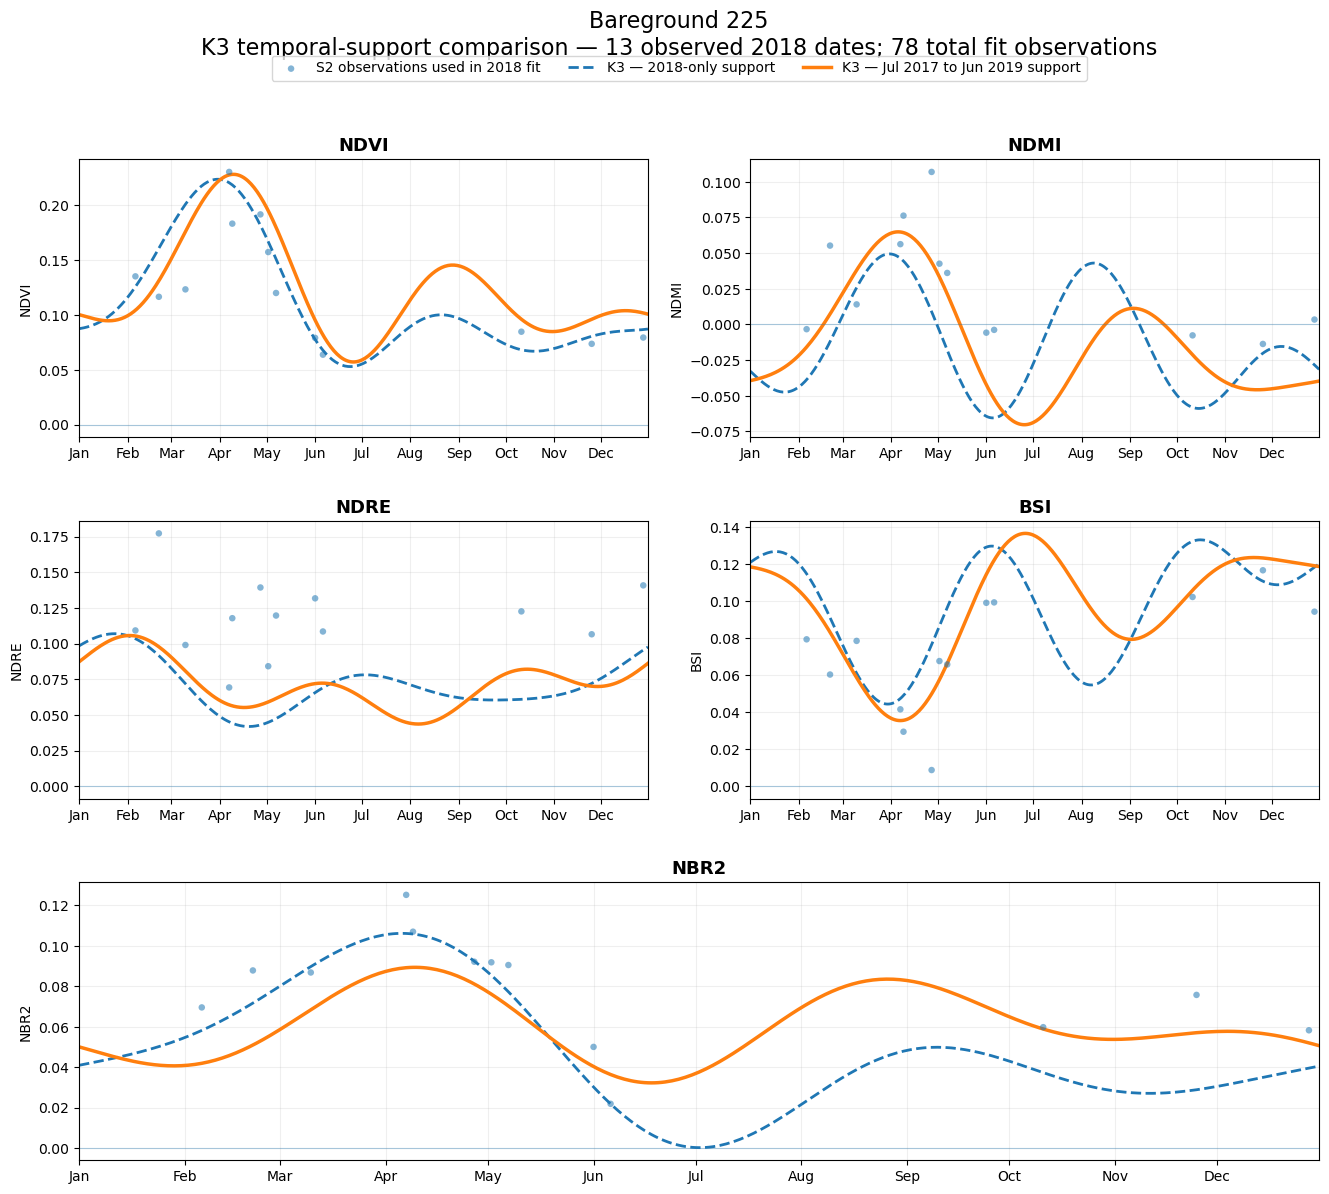

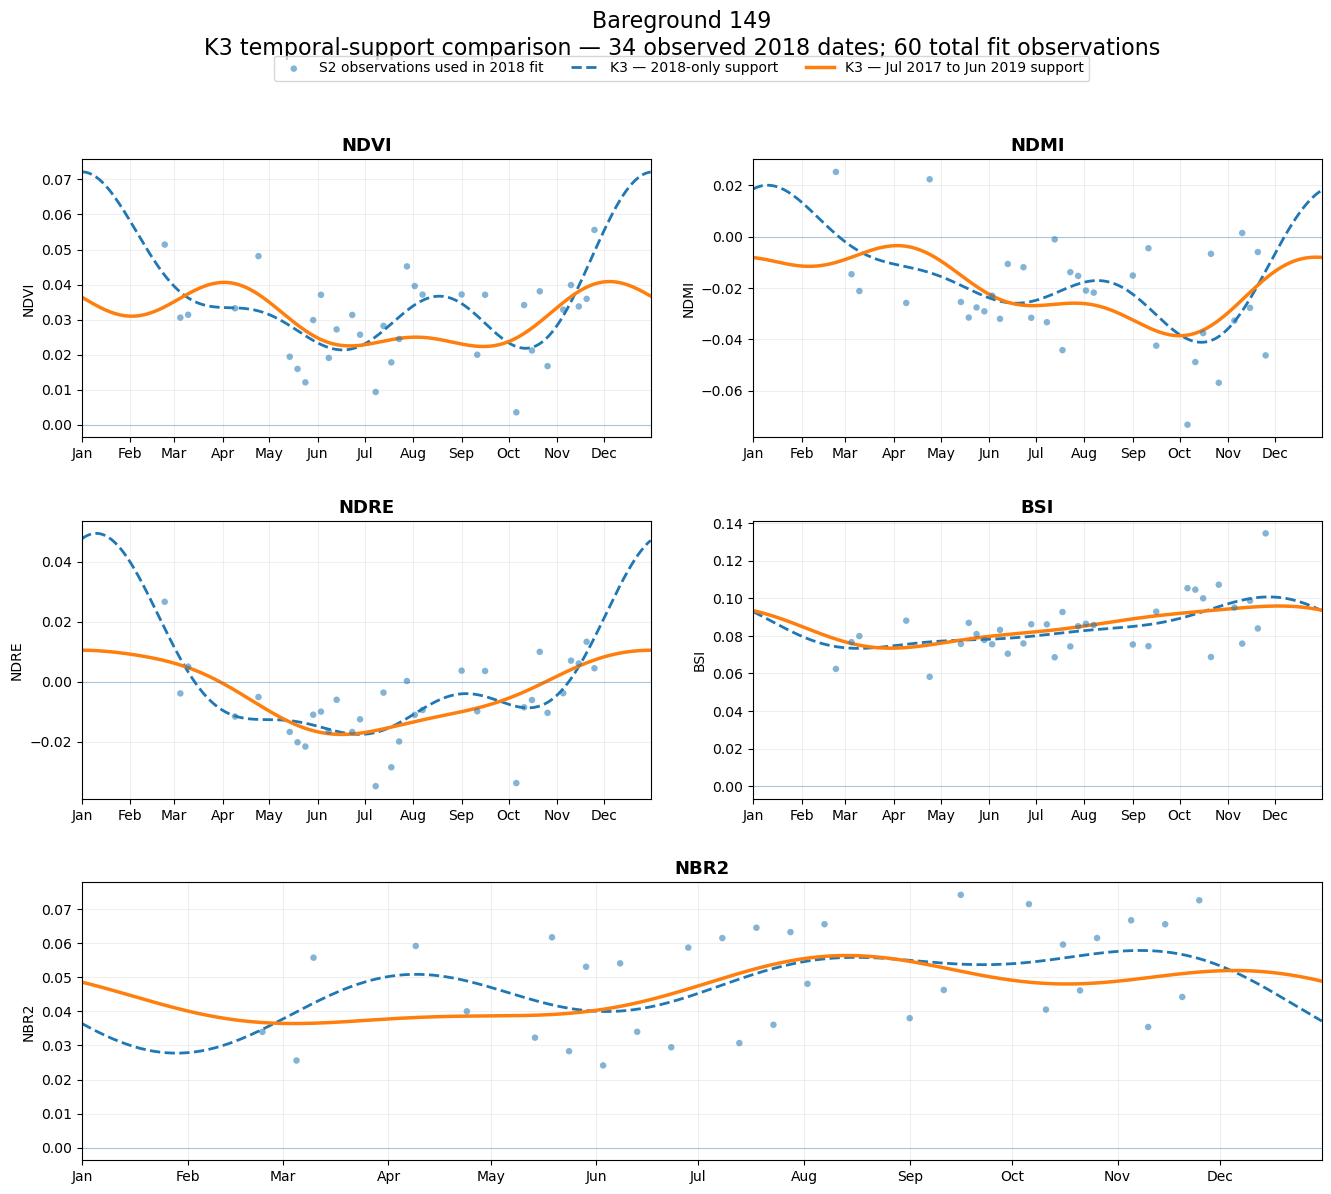

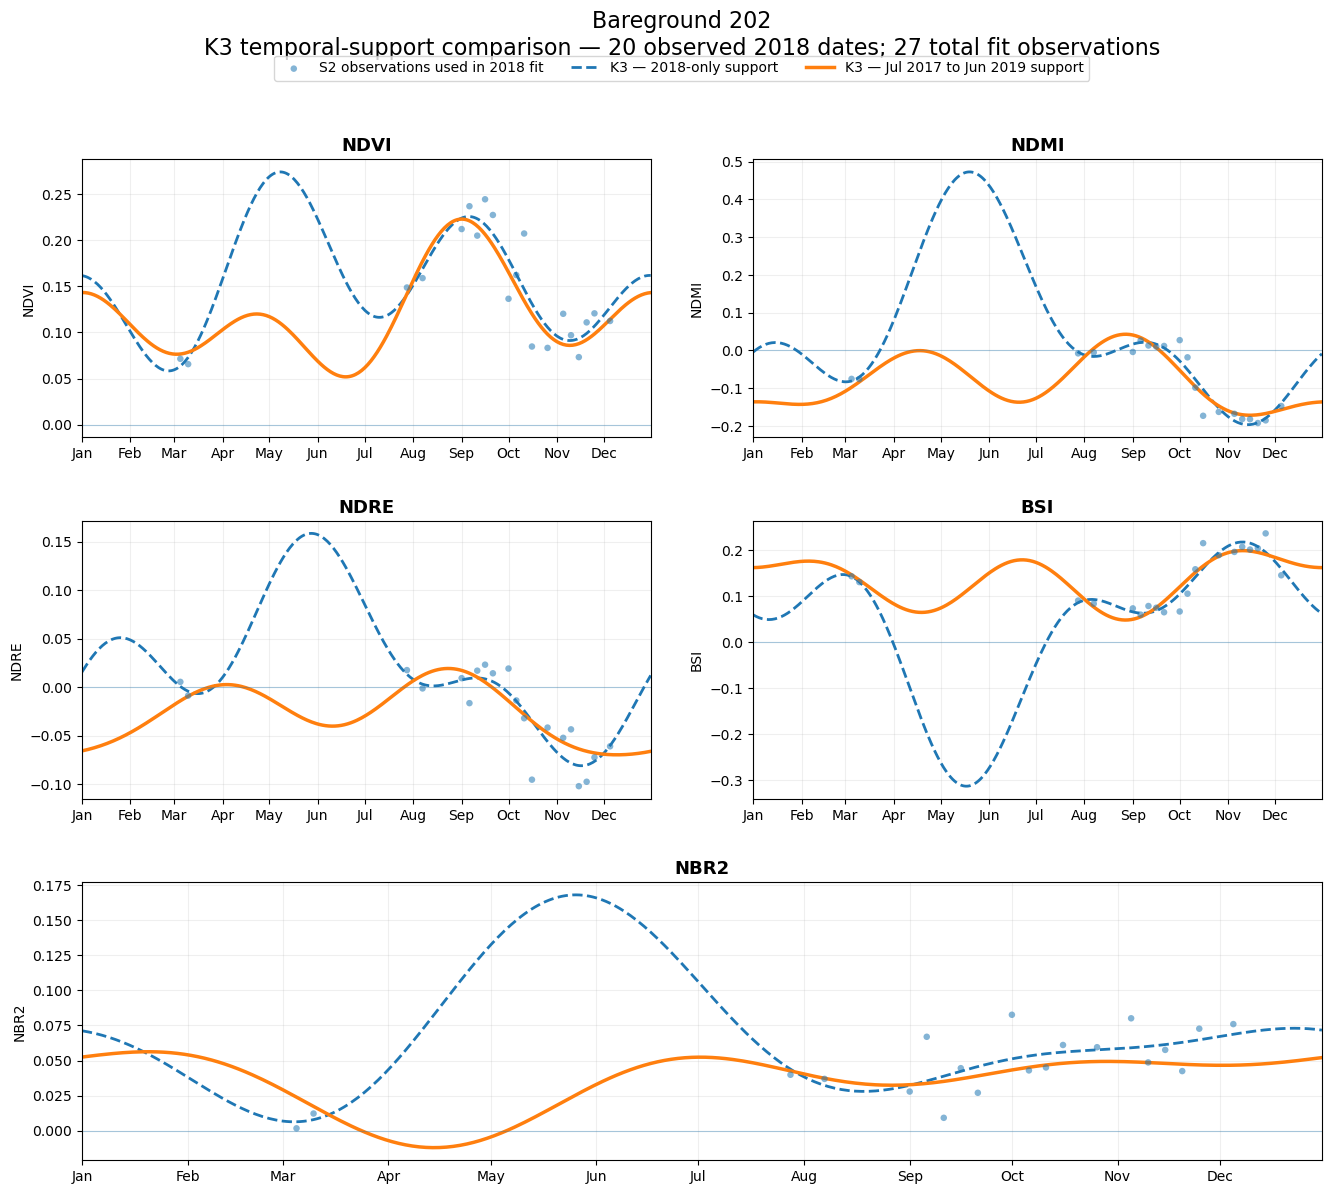

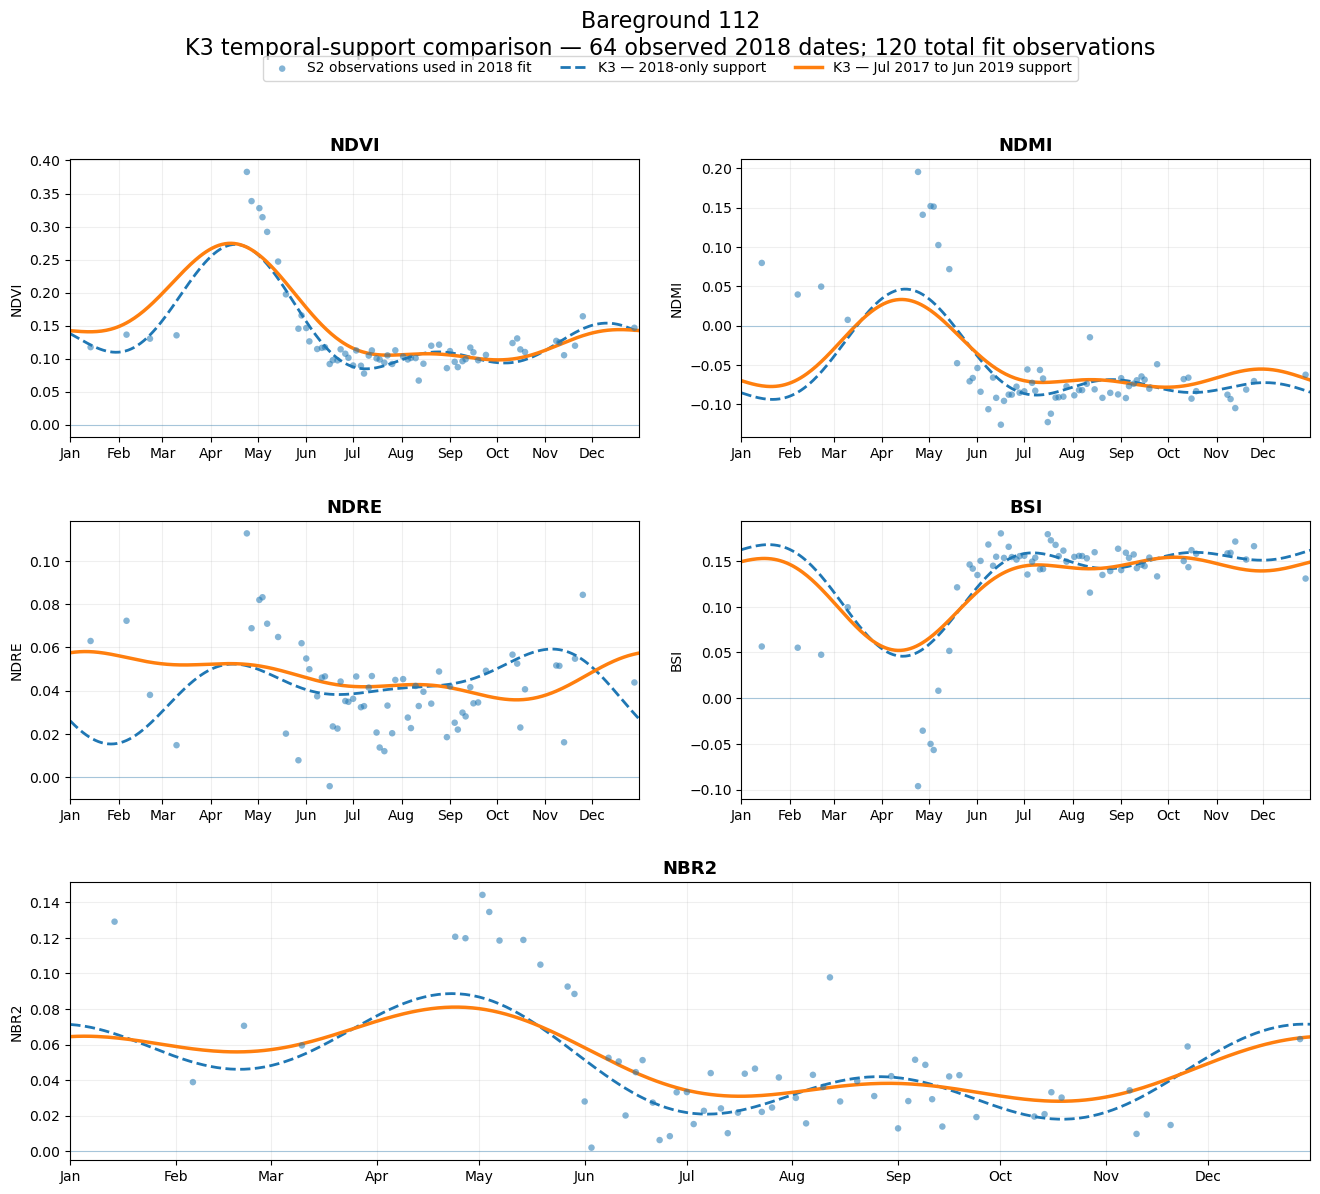

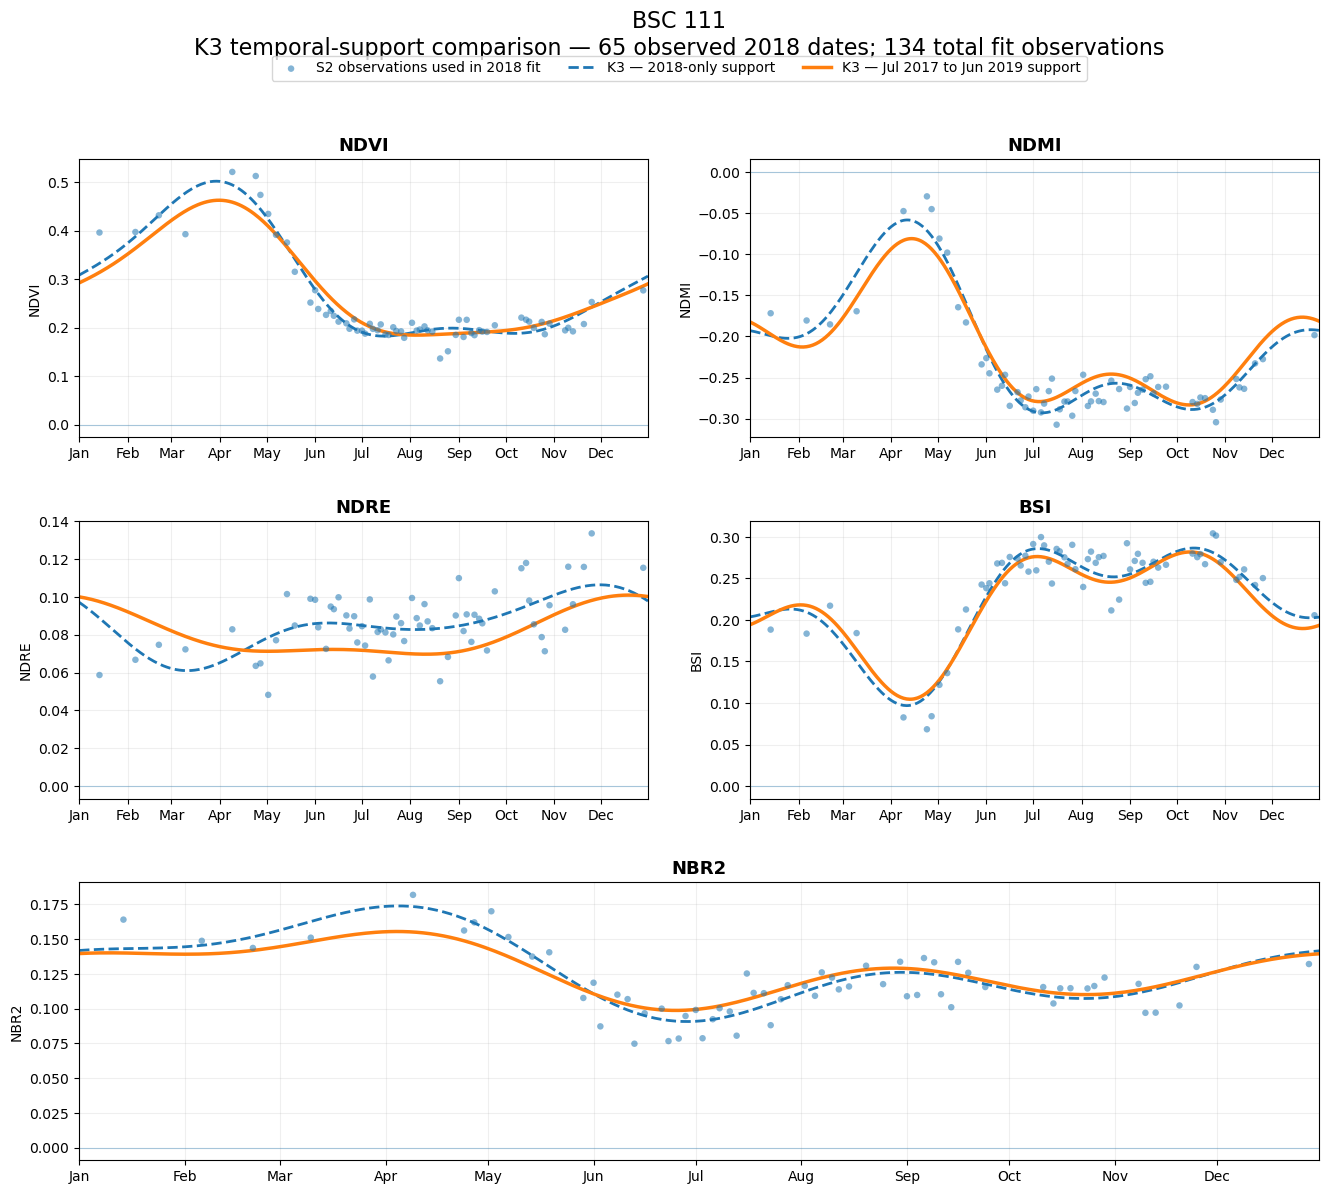

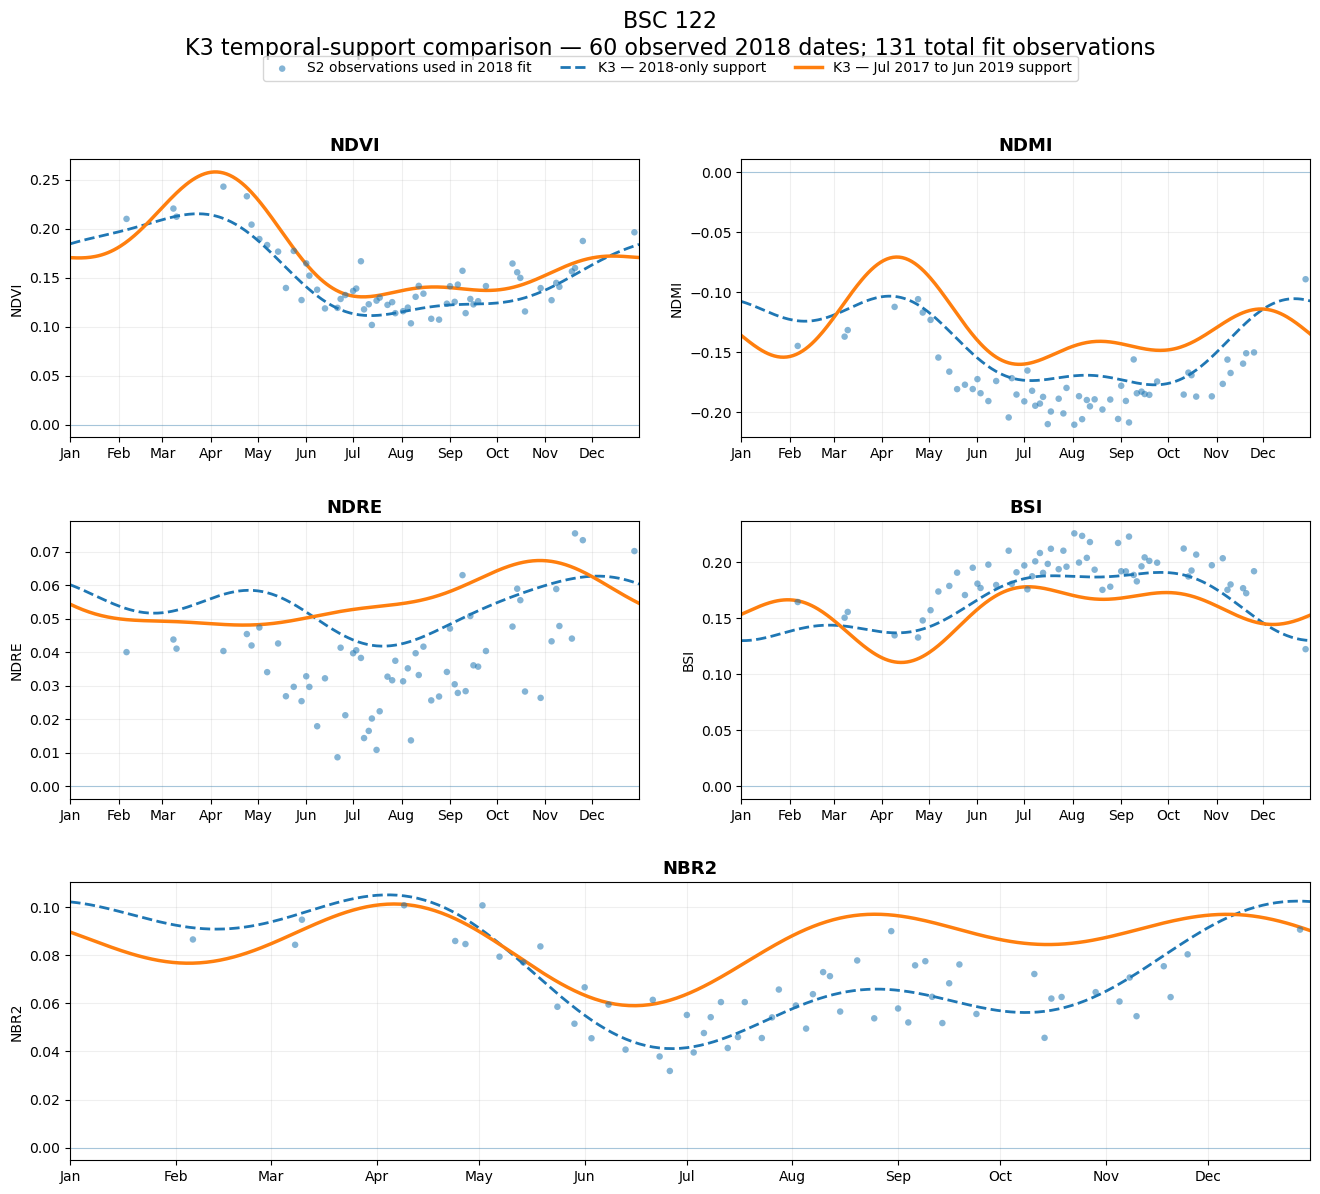

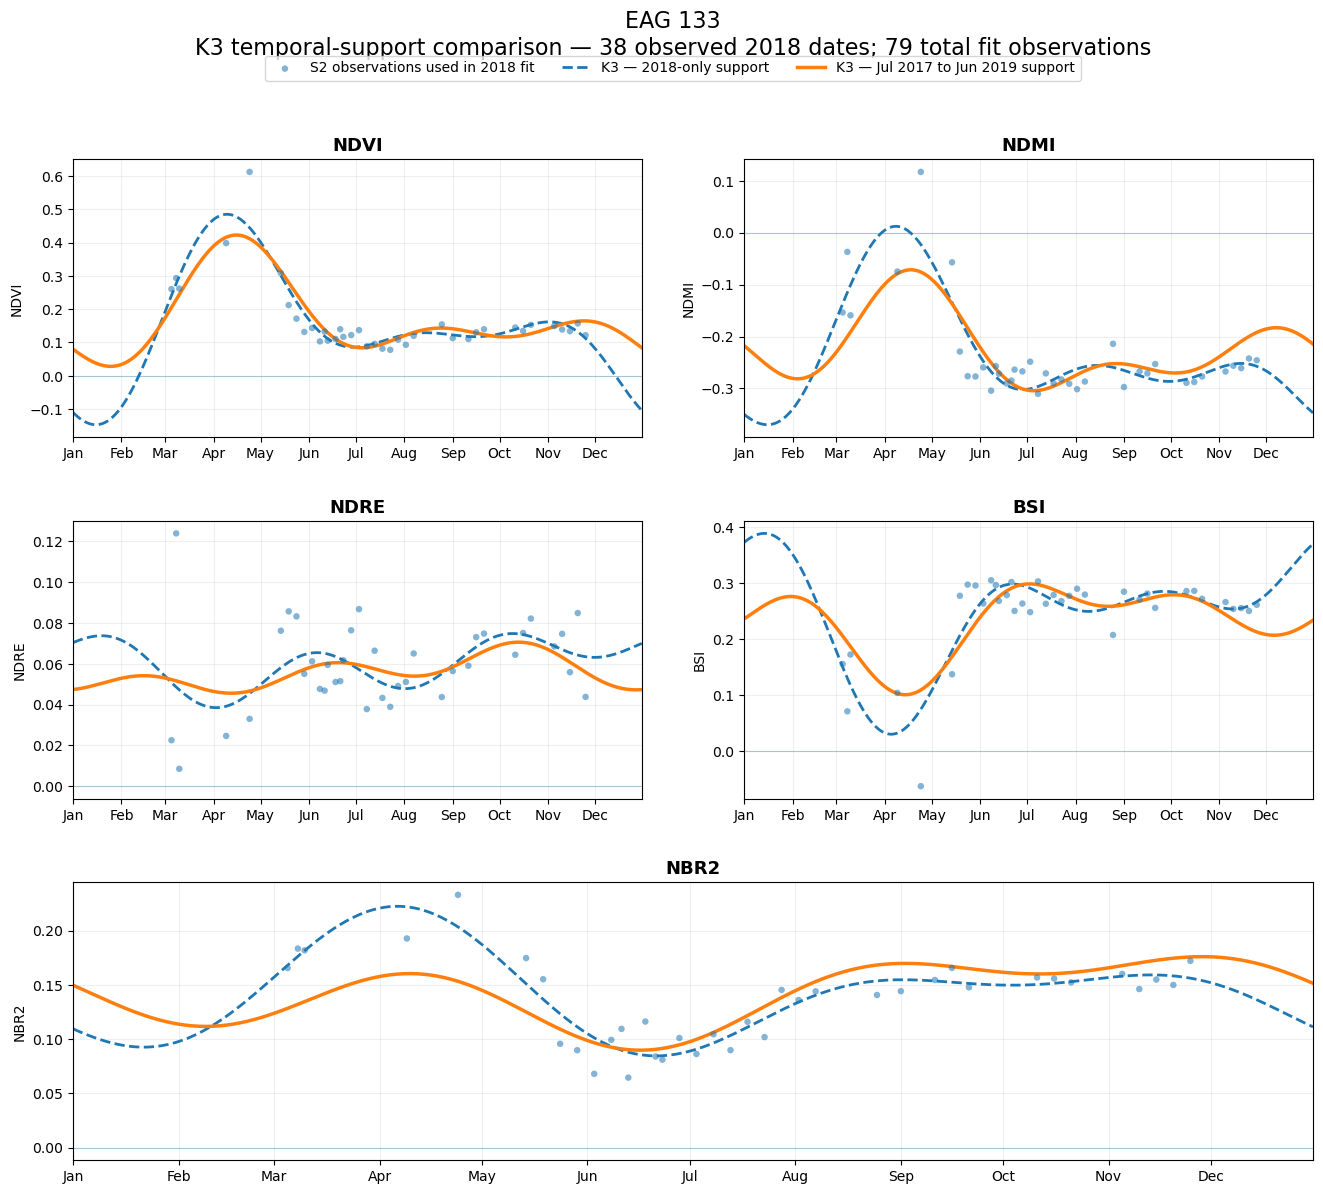

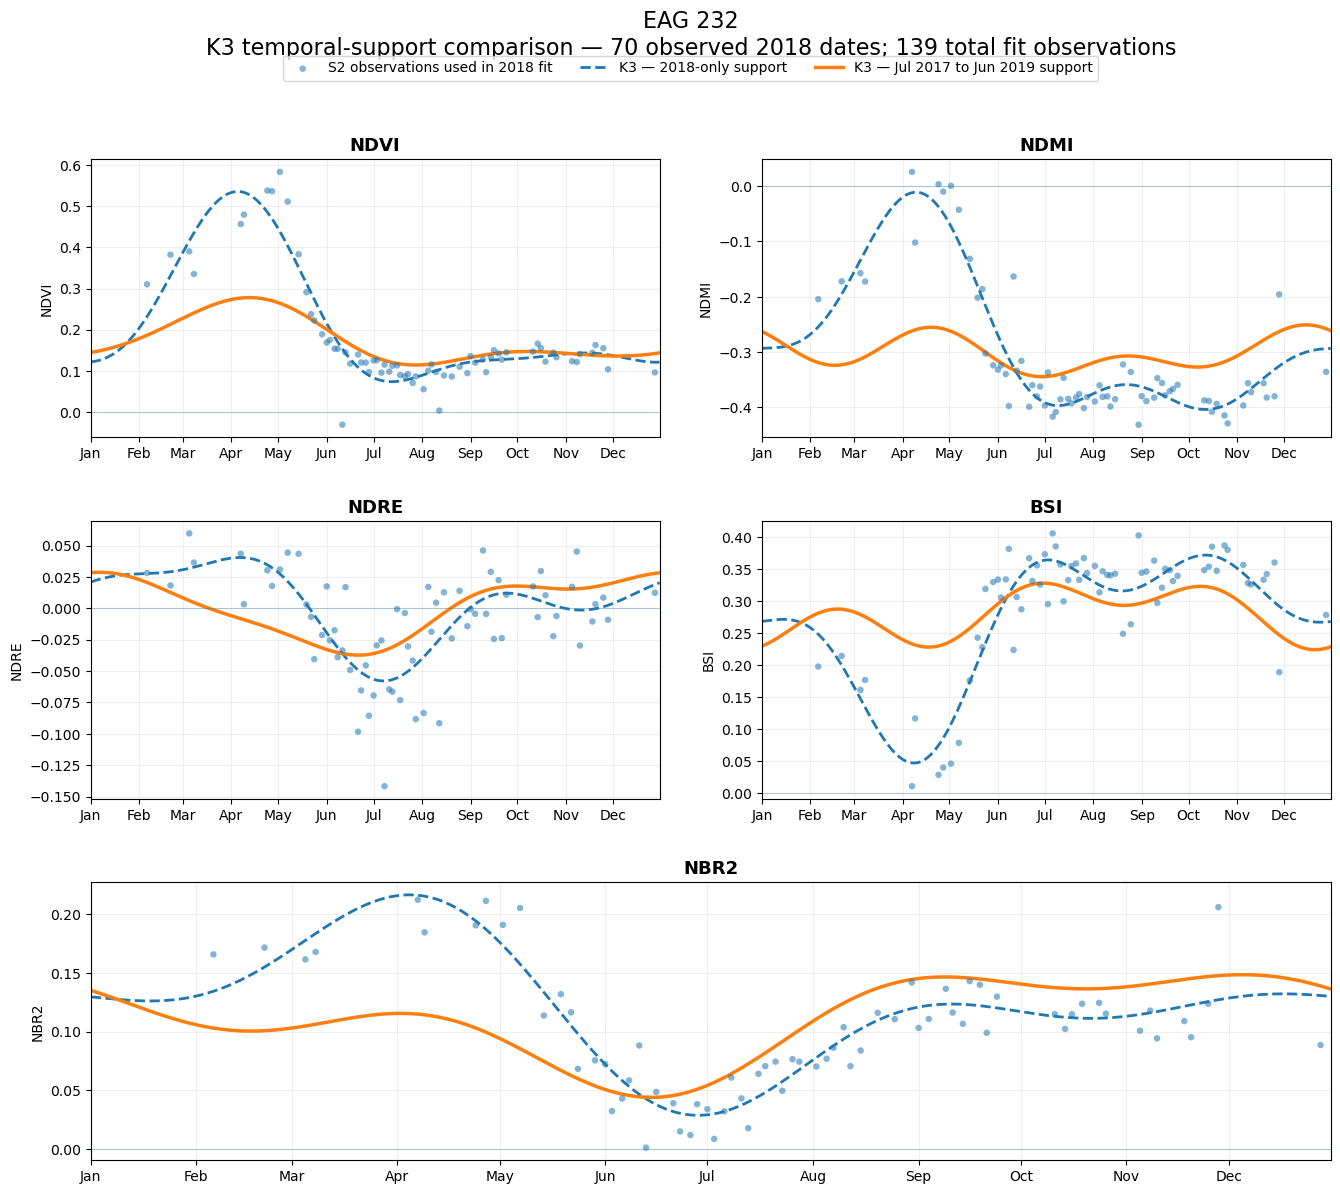

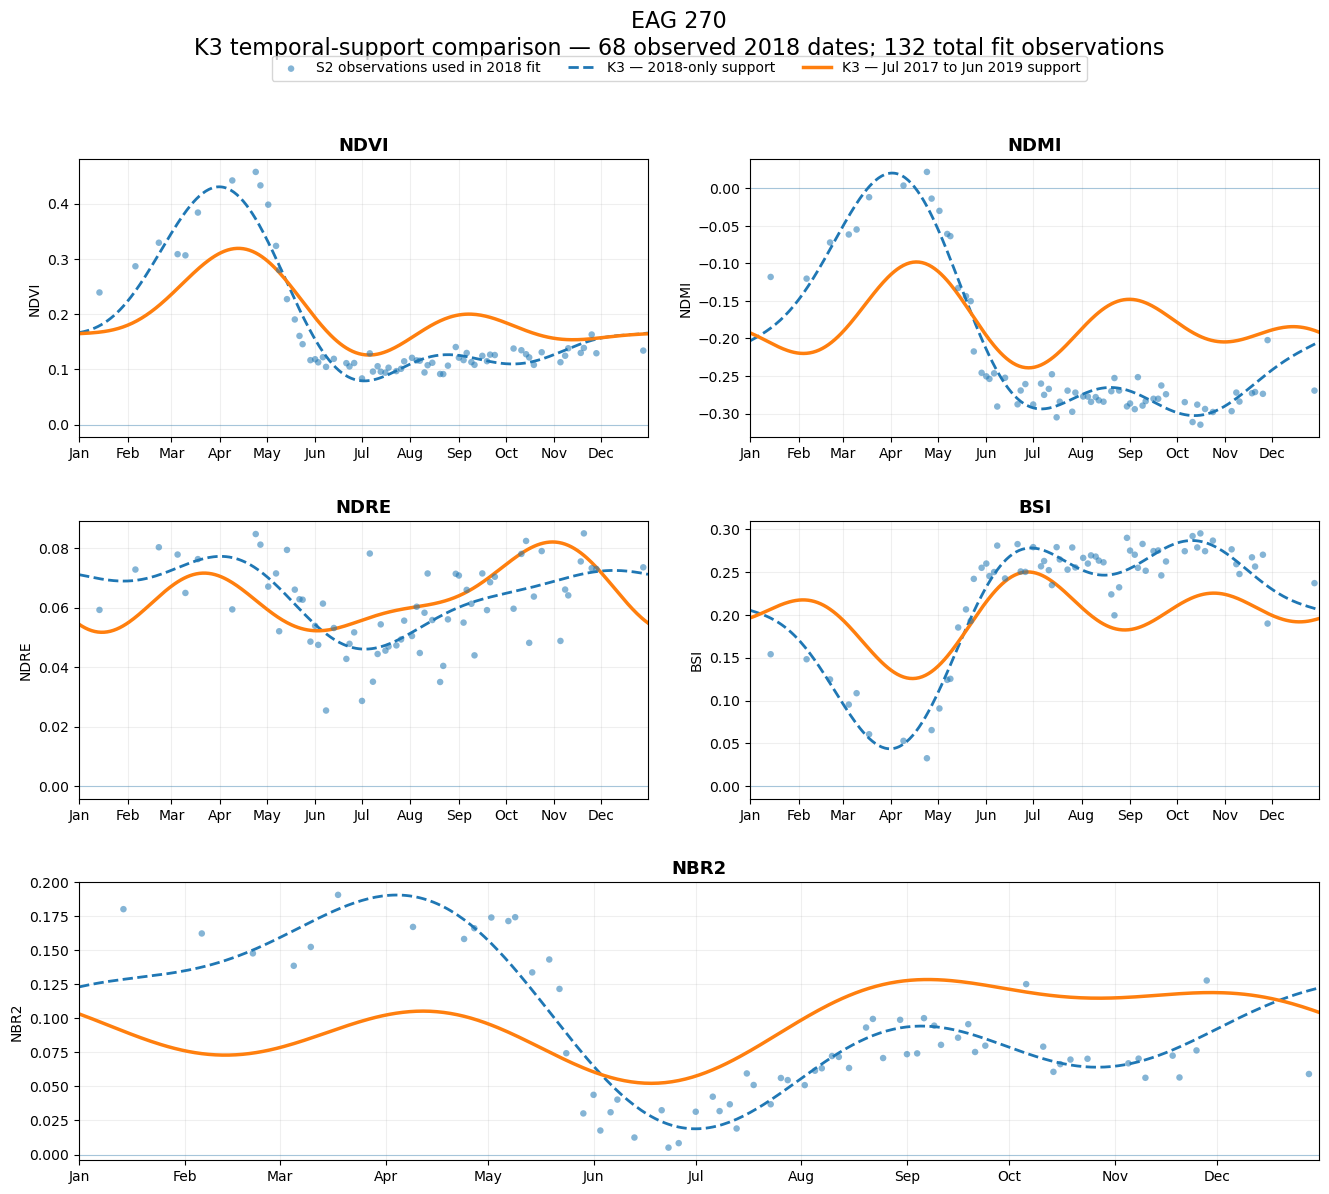

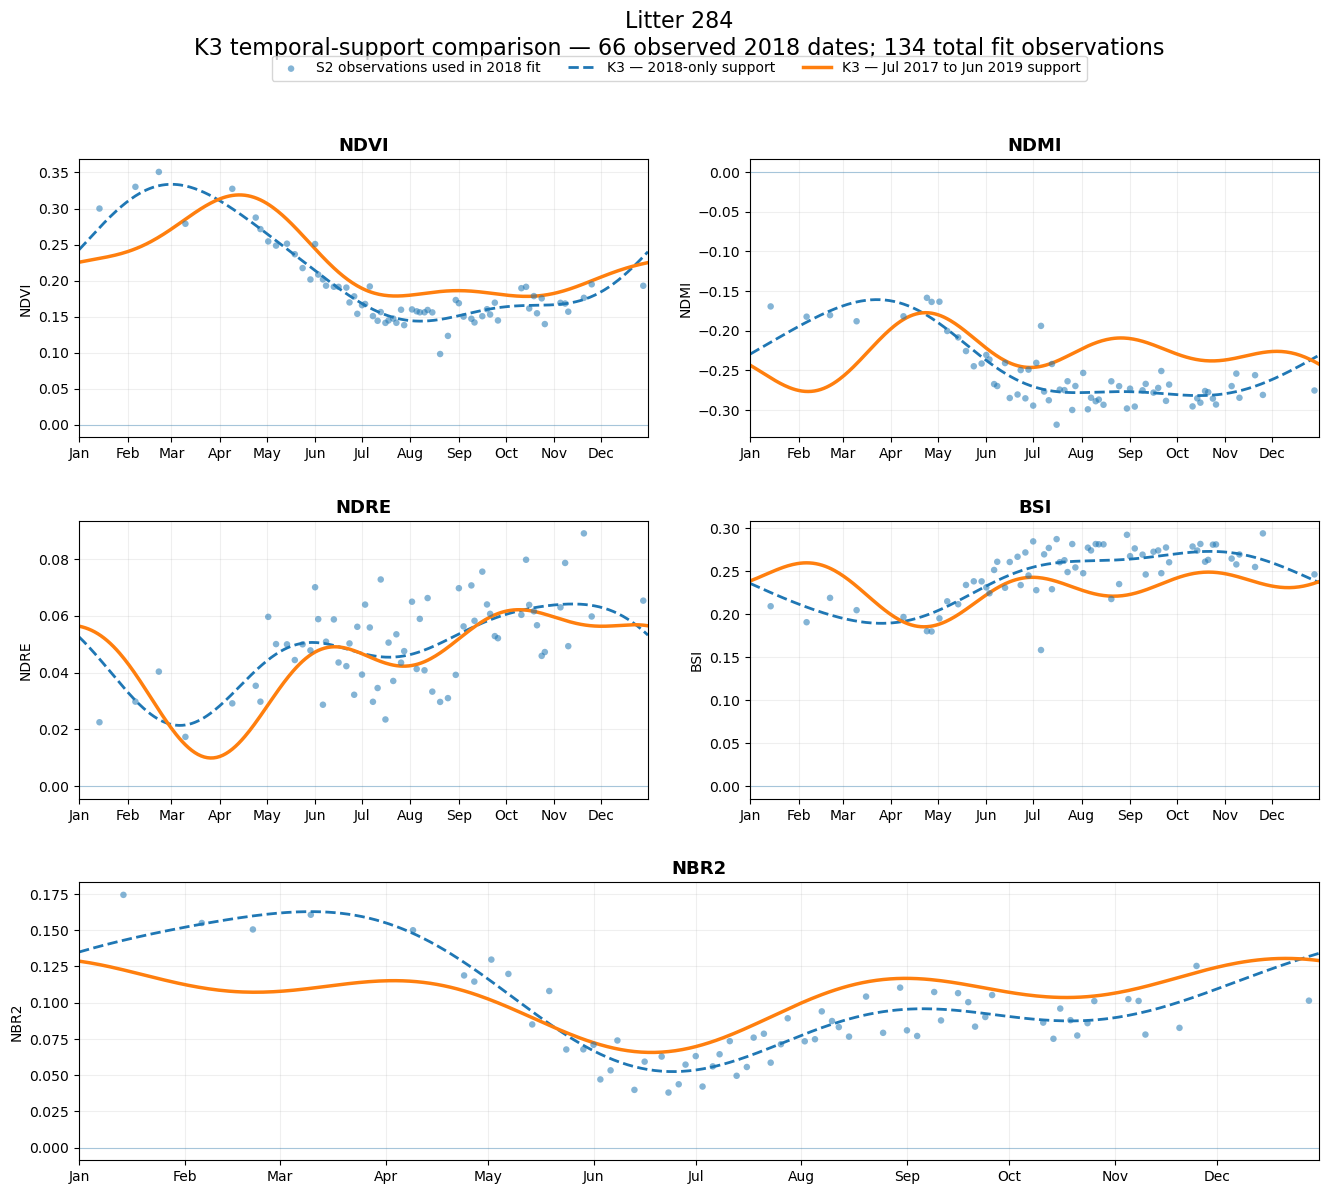

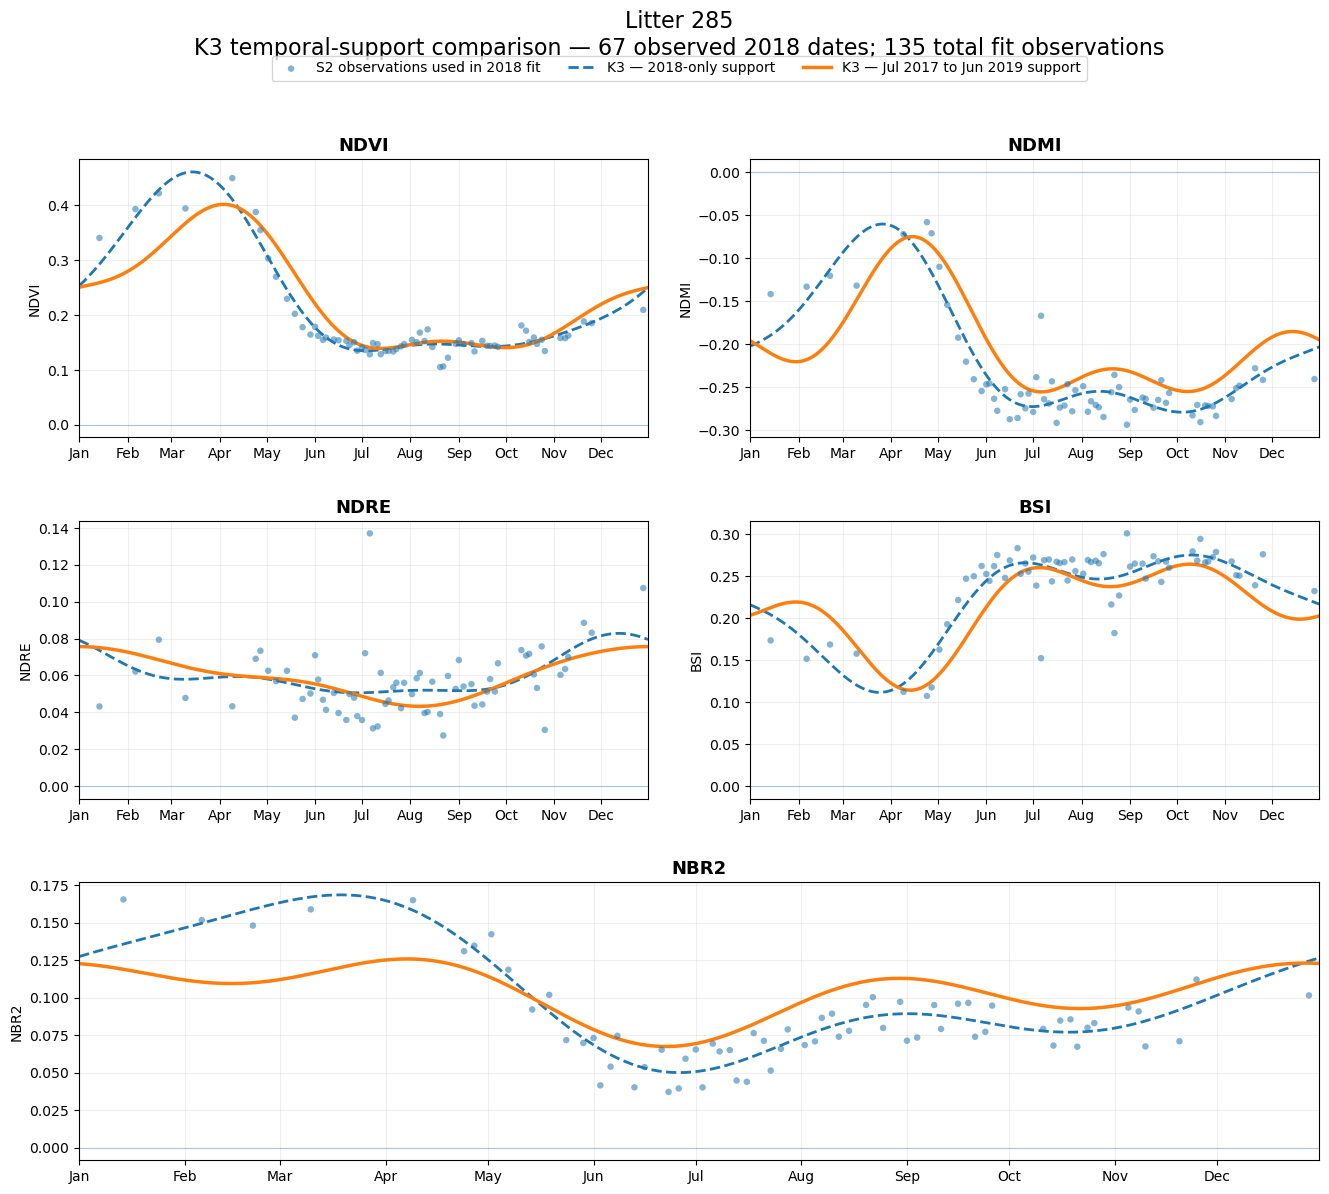

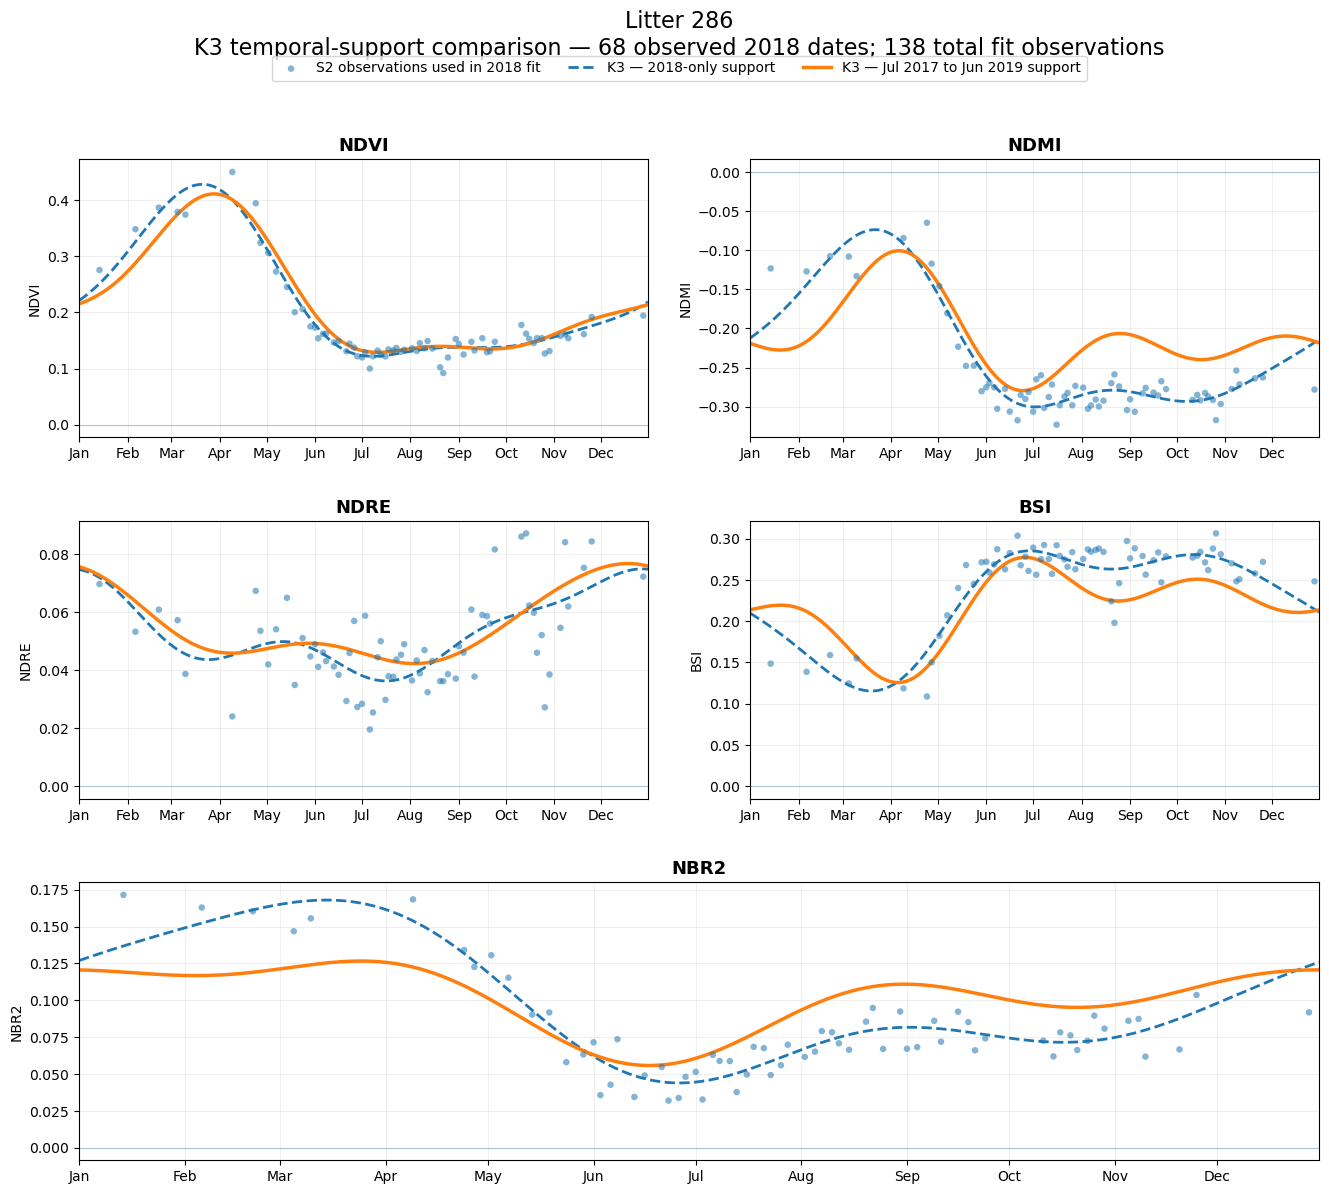

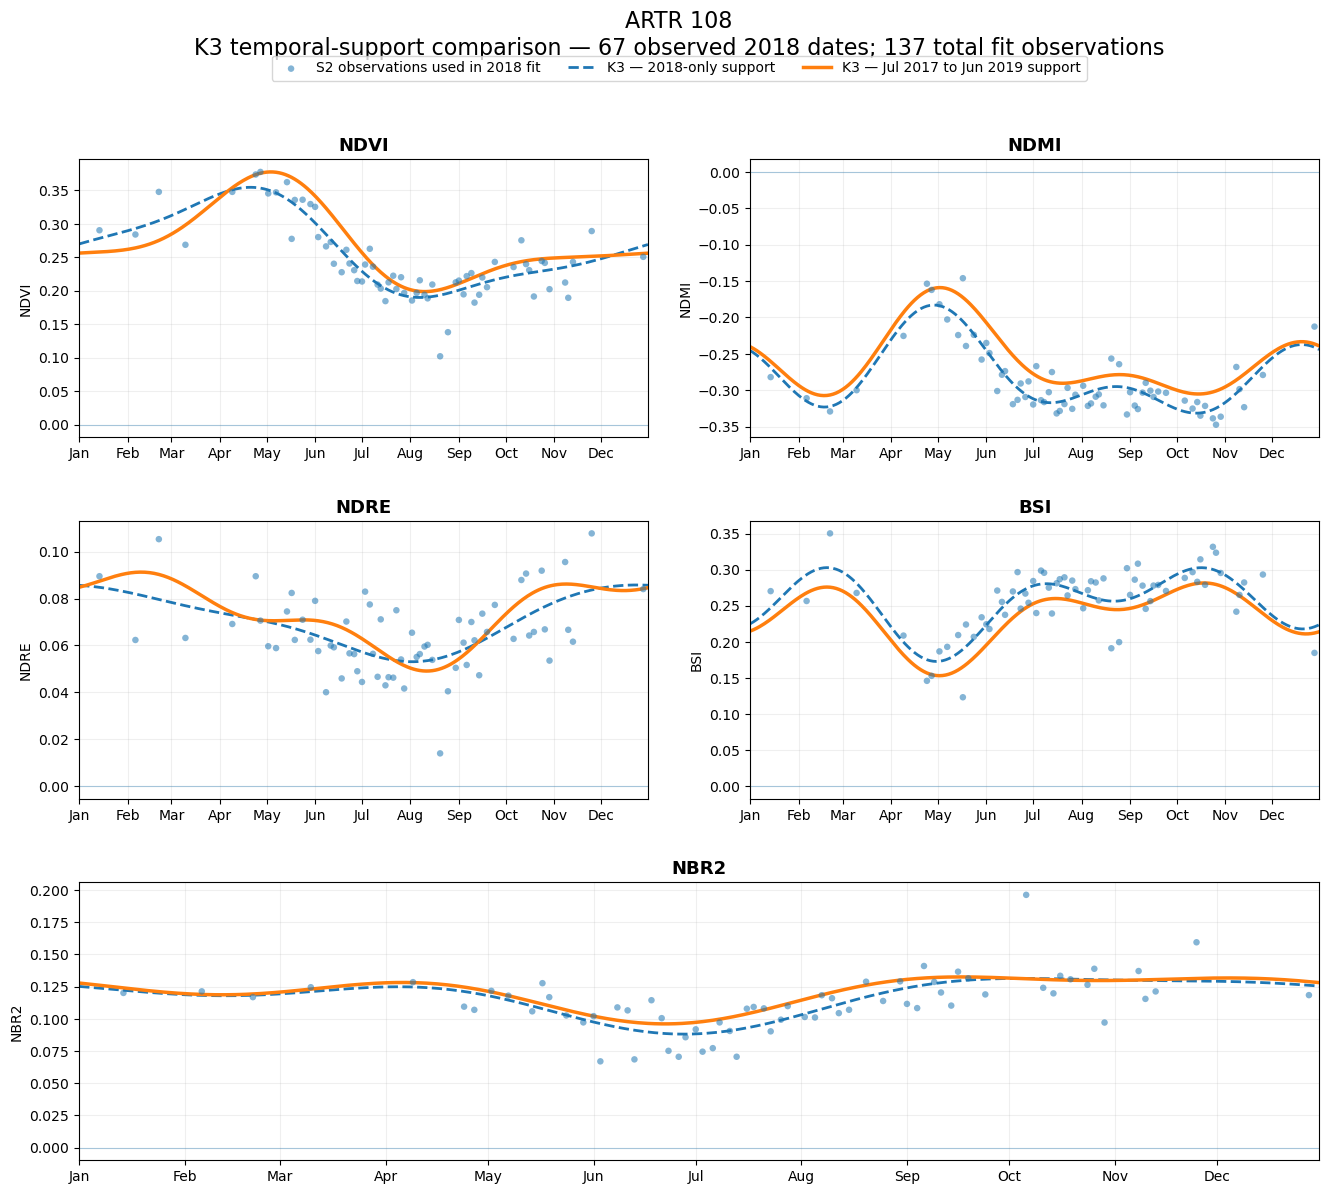

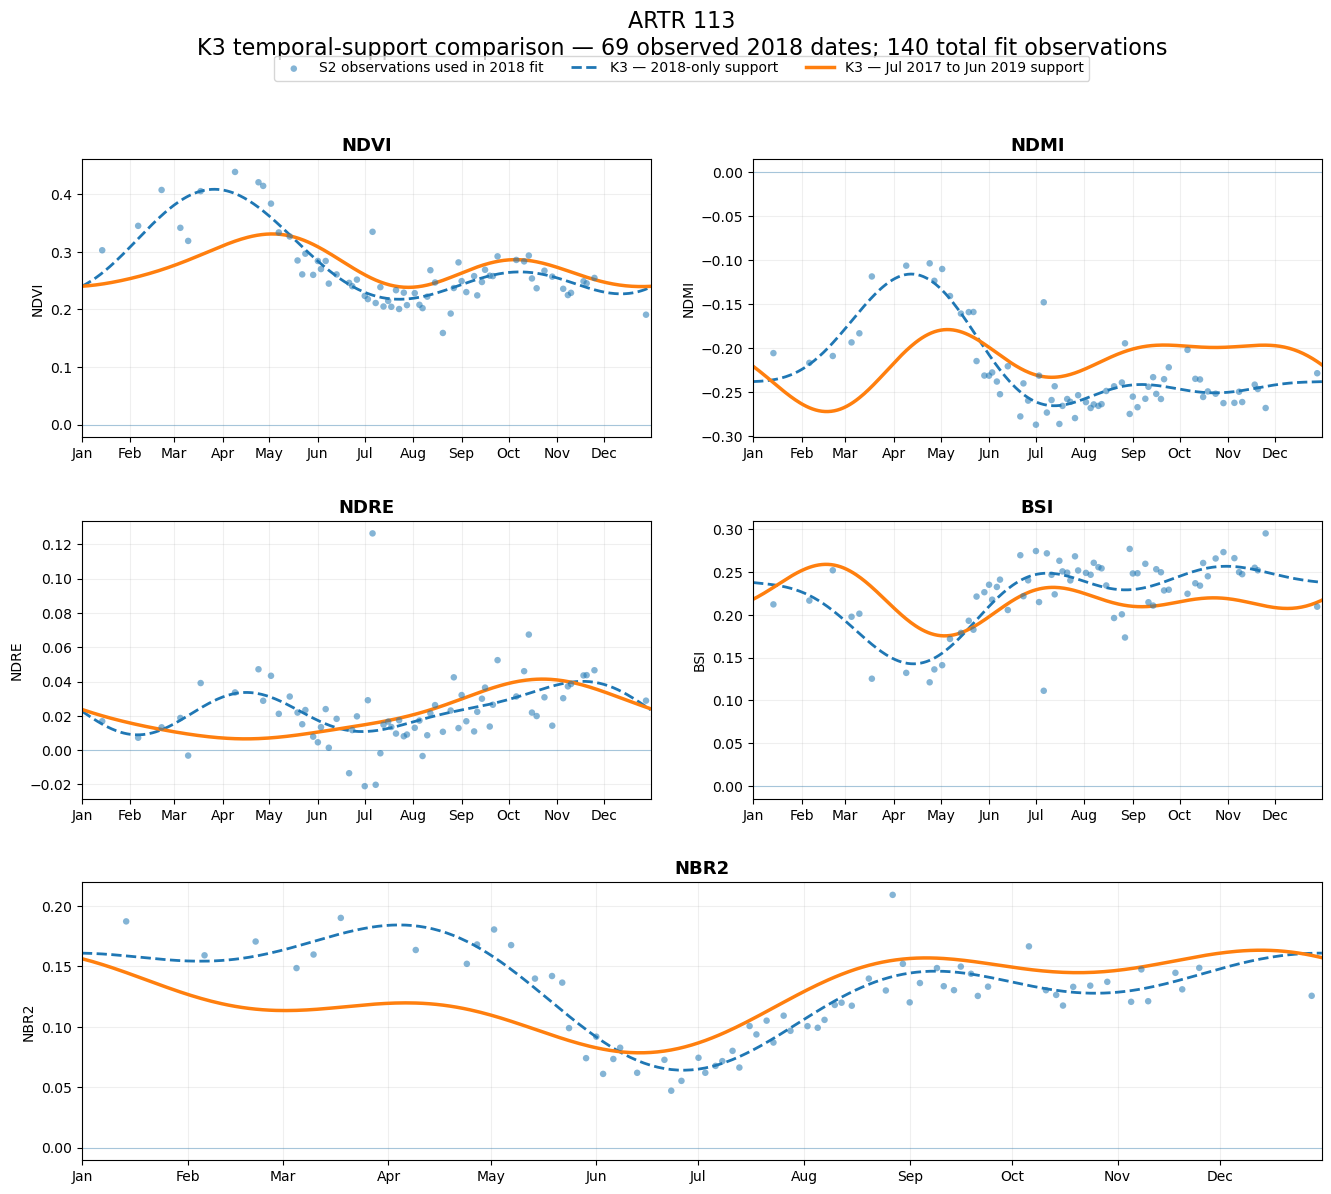

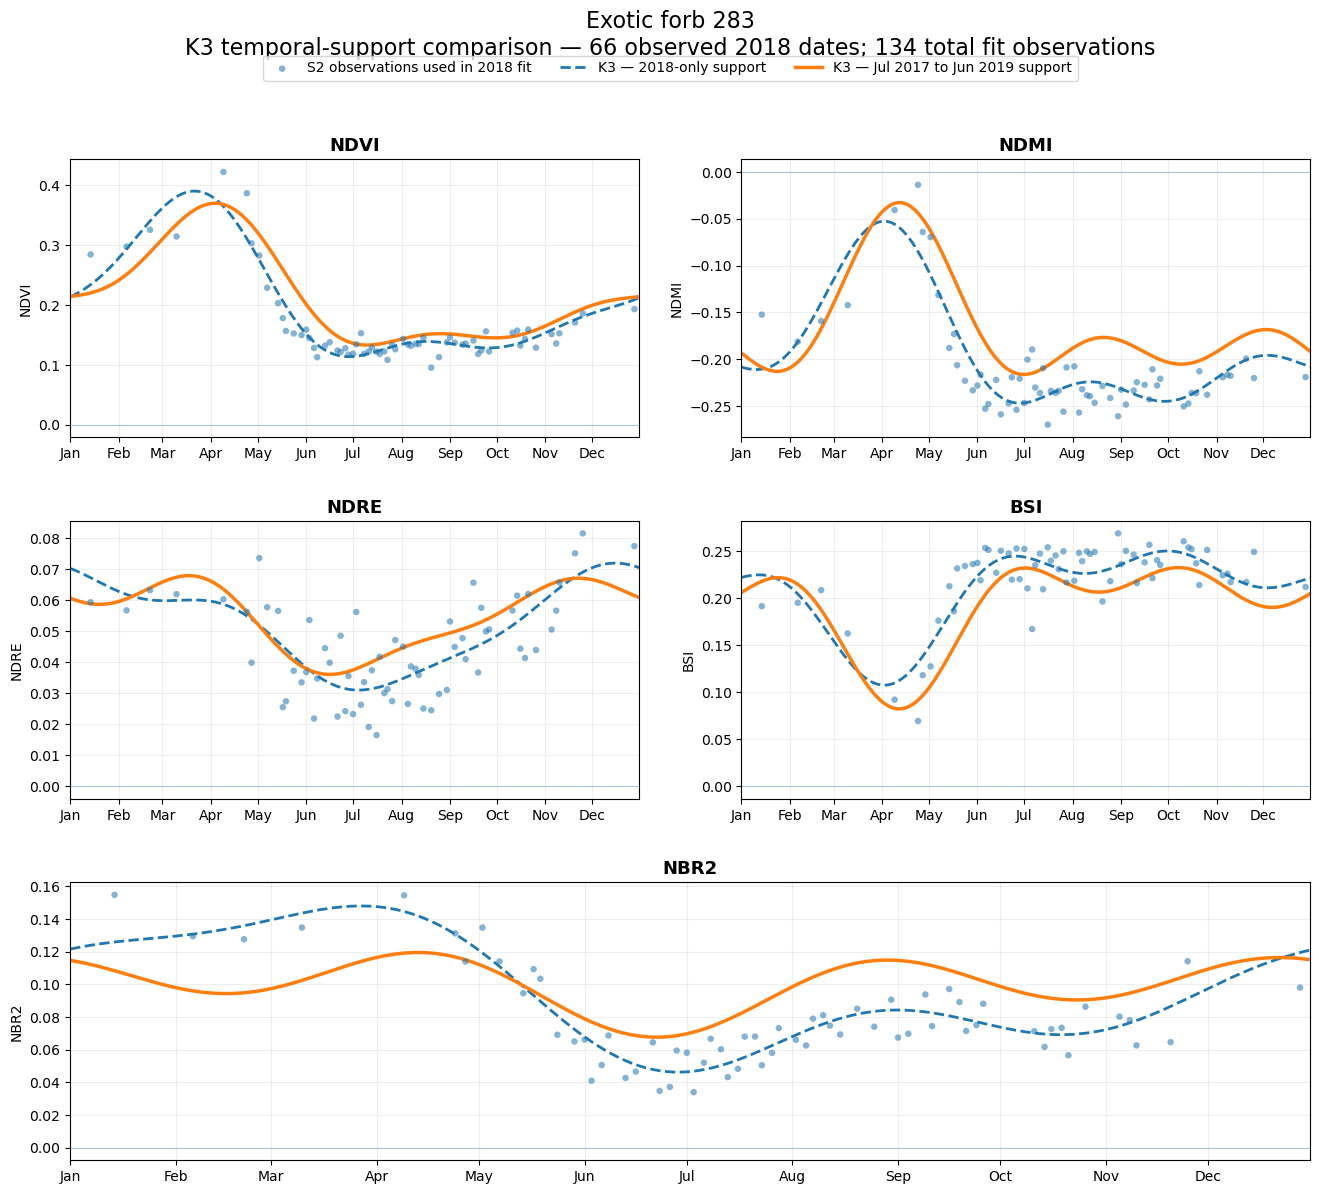

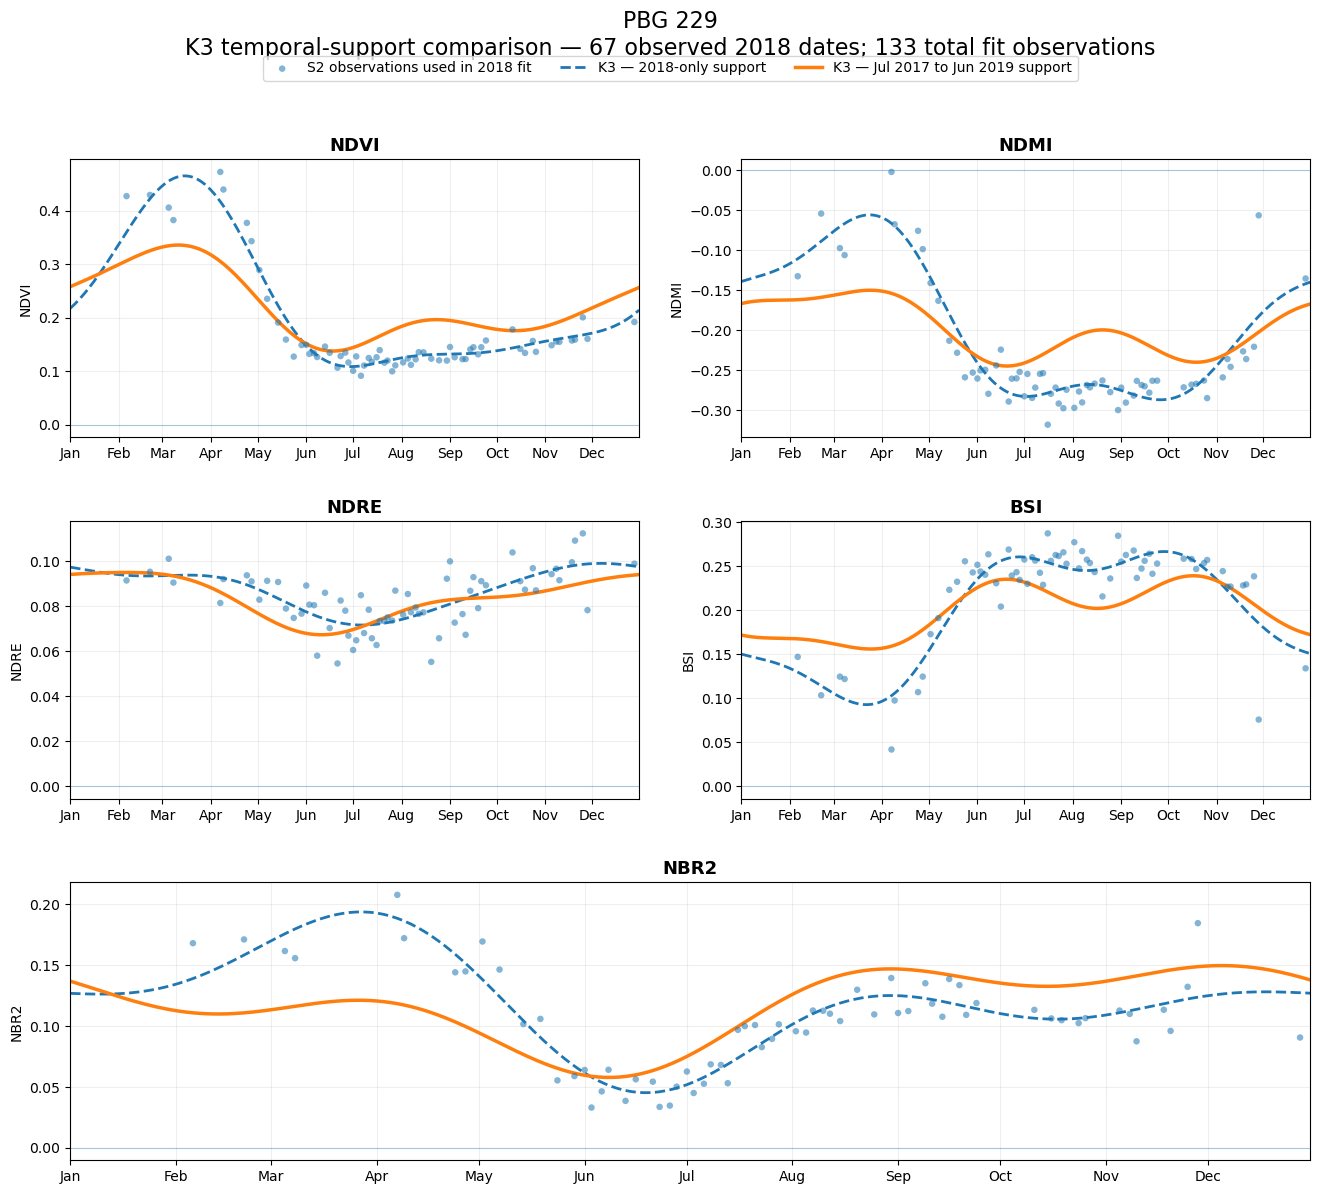

In [9]:
DIAGNOSTIC_PLOTS = {
    "Bareground 225": "225",
    "Bareground 149": "149",
    "Bareground 202": "202",
    "Bareground 112": "112",

    "BSC 111": "111",
    "BSC 122": "122",

    "EAG 133": "133",
    "EAG 232": "232",
    "EAG 270": "270",

    "Litter 284": "284",
    "Litter 285": "285",
    "Litter 286": "286",

    "ARTR 108": "108",
    "ARTR 113": "113",

    "Exotic forb 283": "283",
    "PBG 229": "229",
}


for label, plot_id in DIAGNOSTIC_PLOTS.items():

    plot_pixel_five_indices_padding_comparison(
        plot_id=plot_id,
        title=label,
    )


## 8. RGB + NDVI comparison for an individual field pixel

In [14]:
REFLECTANCE_VARIABLES = [
    ("Red (B4)", "B4", "red"),
    ("Green (B3)", "B3", "green"),
    ("Blue (B2)", "B2", "blue"),
    ("NIR (B8A)", "B8A", "purple"),
    ("SWIR (B11)", "B11", "saddlebrown"),
]


def plot_pixel_reflectance_ndvi_padding_comparison(
    plot_id,
    title=None,
):
    plot_id = str(plot_id)

    raw_plot = (
        raw_long.loc[
            raw_long["PlotID"] == plot_id
        ]
        .copy()
        .sort_values("date")
    )

    if raw_plot.empty:
        raise ValueError(
            f"No valid 2018 observations for PlotID {plot_id}."
        )

    row_original = get_row(
        sampled_original_k3,
        plot_id,
    )

    row_padded = get_row(
        sampled_padded_k3,
        plot_id,
    )

    fig, (ax_refl, ax_ndvi) = plt.subplots(
        2,
        1,
        figsize=(16, 11),
        sharex=True,
        gridspec_kw={"height_ratios": [1.2, 1.0]},
    )

    # --- reflectance panel ---
    for label, variable, color in REFLECTANCE_VARIABLES:

        ax_refl.scatter(
            raw_plot["date"],
            raw_plot[variable],
            s=18,
            alpha=0.35,
            edgecolors="none",
            color=color,
            label=f"{label} observations",
        )

        ax_refl.plot(
            DATES_2018,
            reconstruct_k3_from_derived(
                row_original,
                variable,
            ),
            linestyle="--",
            linewidth=1.8,
            color=color,
            alpha=0.9,
            label=f"{label} — original K3",
        )

        ax_refl.plot(
            DATES_2018,
            reconstruct_k3_from_derived(
                row_padded,
                variable,
            ),
            linewidth=2.3,
            color=color,
            alpha=0.95,
            label=f"{label} — padded K3",
        )

    ax_refl.set_ylabel("Surface reflectance")
    ax_refl.set_title("Reflectance")
    ax_refl.grid(alpha=0.2)
    ax_refl.legend(ncol=3, fontsize=8, loc="best")

    # --- NDVI panel ---
    ax_ndvi.scatter(
        raw_plot["date"],
        raw_plot["NDVI"],
        s=22,
        alpha=0.55,
        edgecolors="none",
        color="gray",
        label="NDVI observations",
    )

    ax_ndvi.plot(
        DATES_2018,
        reconstruct_k3_from_derived(
            row_original,
            "NDVI",
        ),
        linestyle="--",
        linewidth=2.0,
        color="0.35",
        label="NDVI — original K3",
    )

    ax_ndvi.plot(
        DATES_2018,
        reconstruct_k3_from_derived(
            row_padded,
            "NDVI",
        ),
        linewidth=2.5,
        color="0.15",
        label="NDVI — padded K3",
    )

    ax_ndvi.set_ylabel("NDVI")
    ax_ndvi.set_title("NDVI")
    ax_ndvi.grid(alpha=0.2)
    ax_ndvi.legend(loc="best")

    ax_ndvi.set_xlim(
        pd.Timestamp("2018-01-01"),
        pd.Timestamp("2018-12-31"),
    )

    ax_ndvi.xaxis.set_major_locator(
        mdates.MonthLocator()
    )
    ax_ndvi.xaxis.set_major_formatter(
        mdates.DateFormatter("%b")
    )

    if title is None:
        title = f"Plot {plot_id}"

    fig.suptitle(
        f"{title} — original vs 24-month-supported K3",
        fontsize=15,
    )

    fig.tight_layout()
    plt.show()

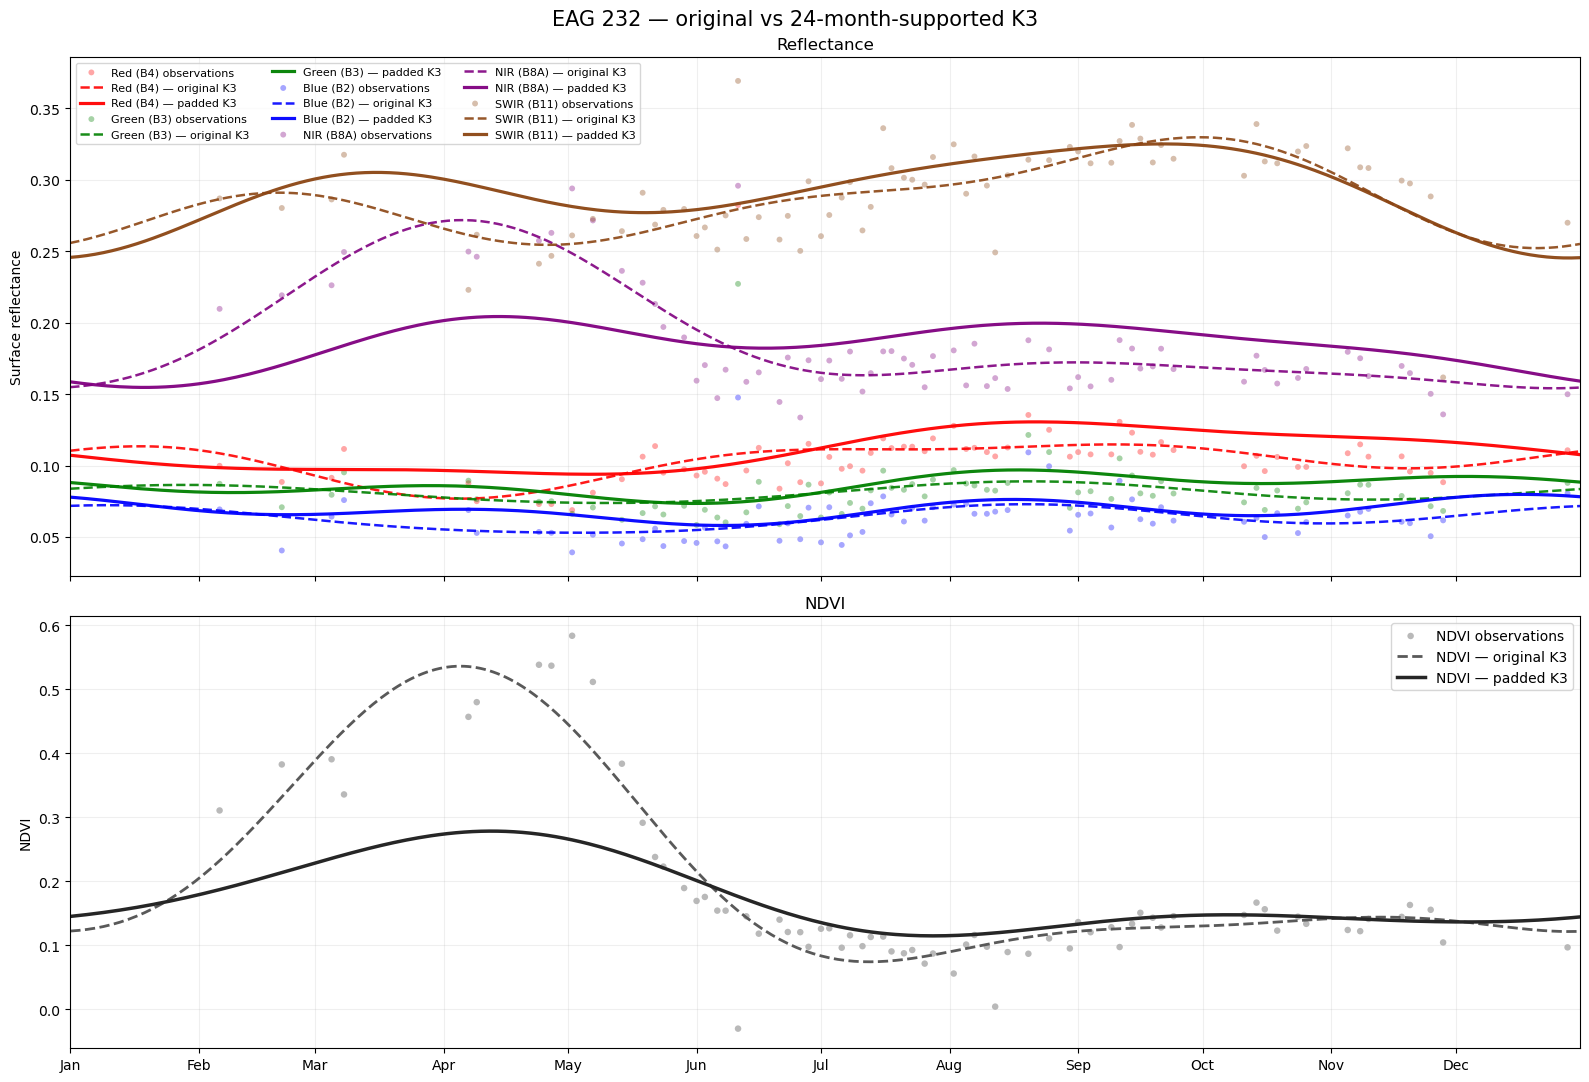

In [16]:
# Example
plot_pixel_reflectance_ndvi_padding_comparison(
    "232",
    title="EAG 232",
)


## 9. Functional-group definitions for the next comparison

These are the corrected endmember groups used in the current review.


In [ ]:
FG_GROUPS = {
    "Bare ground": ["225", "149", "202", "112"],
    "BSC": ["111", "122"],
    "EAG": ["133", "232", "270"],
    "Litter": ["284", "285", "286"],
    "ARTR": ["108", "113"],
}

EXOTIC_FORB_PLOTS = ["283"]
PBG_PLOTS = ["229"]

FG_GROUPS


## Interpretation guardrail

Do **not** compare original `RMSE_*` directly against padded `RMSE_fit_*`: the residuals are evaluated over different observation windows.

For a fair quantitative comparison, compute both models' residuals against the **same 2018 observations** after the padded fit has been inspected visually. The primary immediate test is whether padded K3 stabilizes January/December behavior without materially changing well-supported interior 2018 trajectories.
